# 1. Data Overview

Validate the dataset before drawing conclusions: size, shape, key distributions, and data quality.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

# Anchor to the repo root regardless of where the kernel starts.
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("Repo root:", ROOT)


Repo root: V:\E-commerce Order Fulfillment Operations Analysis


In [2]:
df = pd.read_csv(ROOT / "data" / "processed" / "orders_clean.csv", parse_dates=["Order Date & Time"])
df["is_delayed"] = df["is_delayed"].astype(bool)
print("Rows:", len(df), "| Cols:", df.shape[1])
df.head()

Rows: 100000 | Cols: 16


,Order ID,Customer ID,Platform,Order Date & Time,Promised Delivery (Minutes),Actual Delivery (Minutes),Product Category,Order Value (INR),Items Count,Customer Feedback,Service Rating,Delivery Delay,Refund Requested,is_delayed,order_weekday,order_hour
0,ORD000001,CUST0002,Swiggy Instamart,2024-11-01 00:00:51,35,50,Personal Care,1490,3,"Horrible experience, never ordering again.",1,Yes,Yes,True,4,0
1,ORD000002,CUST0007,Blinkit,2024-11-01 00:05:10,29,24,Personal Care,966,2,Packaging could be better.,3,No,No,False,4,0
2,ORD000003,CUST0002,Swiggy Instamart,2024-11-01 00:08:29,23,16,Grocery,340,5,Product quality was average.,4,No,No,False,4,0
3,ORD000004,CUST0001,Swiggy Instamart,2024-11-01 00:15:19,31,44,Snacks,169,12,Items missing from order.,3,Yes,No,True,4,0
4,ORD000005,CUST0001,Swiggy Instamart,2024-11-01 00:17:23,32,27,Personal Care,172,2,Cold items arrived melted.,2,No,No,False,4,0


## Platform & category mix

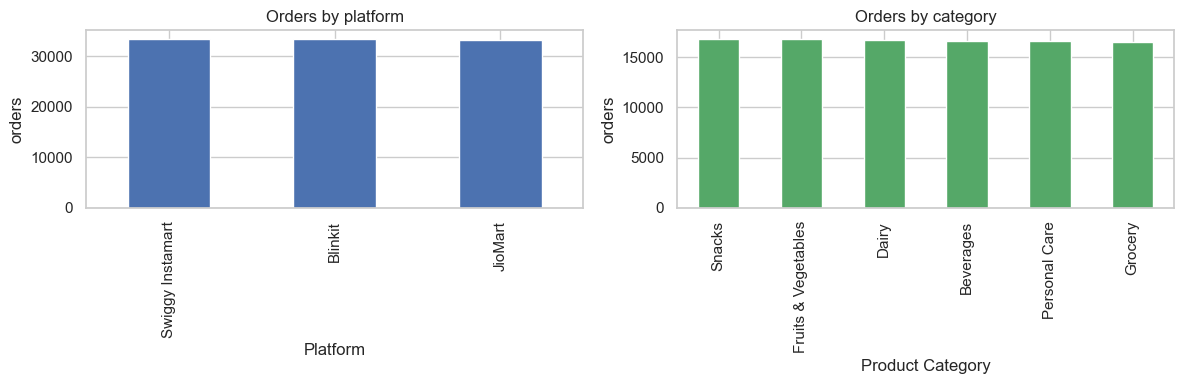

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Platform'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0', title='Orders by platform')
axes[0].set_ylabel('orders')
df['Product Category'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868', title='Orders by category')
axes[1].set_ylabel('orders')
plt.tight_layout(); plt.show()

## Service rating distribution

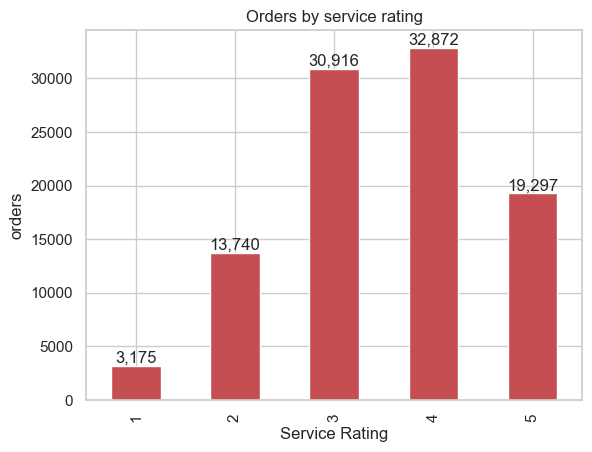

In [4]:
rating_order = sorted(df['Service Rating'].unique())
ax = df['Service Rating'].value_counts().reindex(rating_order).plot(kind='bar', color='#C44E52', title='Orders by service rating')
ax.set_xlabel('Service Rating'); ax.set_ylabel('orders')
for i, v in enumerate(df['Service Rating'].value_counts().reindex(rating_order).values):
    ax.text(i, v + 300, f'{v:,.0f}', ha='center')
plt.show()

## Order value & items

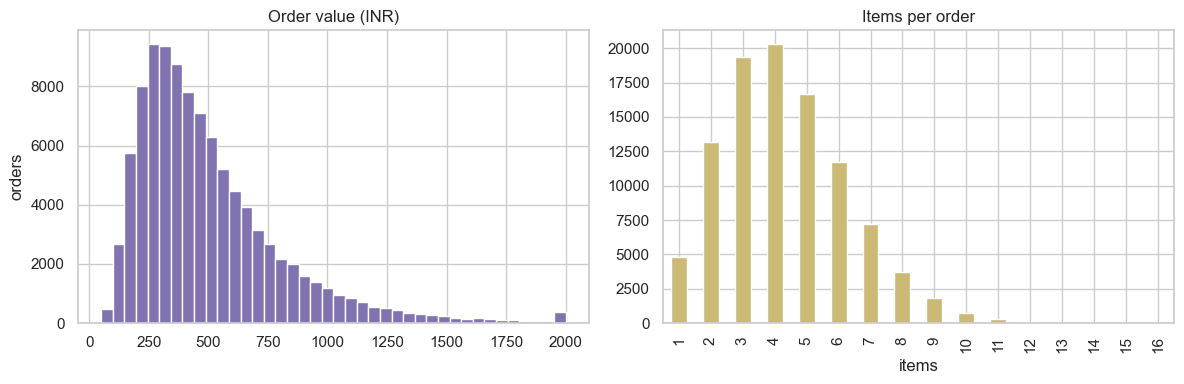

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Order Value (INR)'].hist(bins=40, ax=axes[0], color='#8172B2')
axes[0].set_title('Order value (INR)'); axes[0].set_ylabel('orders')
df['Items Count'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#CCB974')
axes[1].set_title('Items per order'); axes[1].set_xlabel('items')
plt.tight_layout(); plt.show()

## Key takeaways
- The clean table has **100,000 orders**, **2,302 distinct customers**, 3 platforms and 6 categories.
- All timestamps parse as real datetimes (the original dataset shipped a corrupted `Order Date & Time`).
- Ratings are right-skewed toward 4-5, but every rating is well populated, so per-rating refund analysis is robust.
- Order value is roughly log-normal (mean ~500 INR); items-per-order peaks at 3-5.
- **This notebook reproduces the sanity checks in `SQL/data_overview.sql`.**